1. Setup

In [1]:
# =========================================================
# Librerías base
# =========================================================

# Manejo de rutas y sistema
import os
import sys
import importlib

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Configuración estética para las gráficas
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Detecta la raíz del proyecto.
# Como el notebook está dentro de /notebooks,
# usamos ".." para subir a la carpeta raíz del proyecto.
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz del proyecto al path de Python
# para poder importar utils.config
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa la configuración del proyecto y la recarga
# por si se modificó recientemente
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

# ---------------------------------------------------------
# Imprime la ruta donde están los artefactos del flujo full
# ---------------------------------------------------------
print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)

FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full


2. Función auxiliar para cargar resultados

In [2]:
# ---------------------------------------------------------
# Esta función intenta cargar un archivo CSV de resultados.
# Si el archivo existe, lo carga y añade la columna "task".
# Si no existe, devuelve un DataFrame vacío.
#
# Esto permite que el notebook no falle si falta algún archivo.
# ---------------------------------------------------------
def load_results_if_exists(path, task):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["task"] = task
        return df
    else:
        print(f"No encontrado: {path}")
        return pd.DataFrame()

3. Cargar resultados multiclase full

In [3]:
# ---------------------------------------------------------
# Carga los resultados de modelos clásicos de ML
# para el problema multiclase en el dataset full
# ---------------------------------------------------------
multiclass_ml = load_results_if_exists(
    os.path.join(config.FULL_ARTIFACTS_DIR, "multiclass_model_results_full.csv"),
    task="multiclass"
)

# ---------------------------------------------------------
# Carga los resultados del DNN multiclase full
# ---------------------------------------------------------
multiclass_dnn = load_results_if_exists(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_multiclass_results_full.csv"),
    task="multiclass"
)

# ---------------------------------------------------------
# Une ambos resultados si existen
# ---------------------------------------------------------
multiclass_frames = [df for df in [multiclass_ml, multiclass_dnn] if not df.empty]

multiclass_results = (
    pd.concat(multiclass_frames, ignore_index=True, sort=False)
    if multiclass_frames else pd.DataFrame()
)

print("Resultados multiclase:")
display(multiclass_results)

Resultados multiclase:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,task
0,Random Forest Full,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290,multiclass
1,LightGBM Full,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039,multiclass
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743,multiclass
3,DNN Full Multiclass,0.858036,0.877164,0.858036,0.855430,0.681876,0.653672,0.658307,multiclass


4. Cargar resultados binarios full

In [4]:
# ---------------------------------------------------------
# Carga los resultados de modelos clásicos de ML
# para el problema binario en el dataset full
# ---------------------------------------------------------
binary_ml = load_results_if_exists(
    os.path.join(config.FULL_ARTIFACTS_DIR, "binary_model_results_full.csv"),
    task="binary"
)

# ---------------------------------------------------------
# Carga los resultados del DNN binario full
# ---------------------------------------------------------
binary_dnn = load_results_if_exists(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_binary_results_full.csv"),
    task="binary"
)

# ---------------------------------------------------------
# Une ambos resultados si existen
# ---------------------------------------------------------
binary_frames = [df for df in [binary_ml, binary_dnn] if not df.empty]

binary_results = (
    pd.concat(binary_frames, ignore_index=True, sort=False)
    if binary_frames else pd.DataFrame()
)

print("Resultados binarios:")
display(binary_results)

Resultados binarios:


,model,accuracy,precision,recall,f1,roc_auc,task
0,Random Forest Binary Full,0.980129,0.999739,0.979650,0.989592,0.998654,binary
1,LightGBM Binary Full,0.978305,0.999759,0.977739,0.988626,0.998965,binary
2,XGBoost Binary Full,0.977875,0.999725,0.977326,0.988399,0.998773,binary
3,DNN Full Binary,0.971413,0.997395,0.972897,0.984994,0.990358,binary


5. Normalizar nombres de modelos

In [5]:
# ---------------------------------------------------------
# Esta función normaliza nombres de modelos para que en las
# gráficas no aparezcan variantes largas como:
# "Random Forest Full", "DNN Full Multiclass", etc.
#
# Se reemplazan por nombres más simples:
# "Random Forest", "XGBoost", "LightGBM", "DNN"
# ---------------------------------------------------------
def normalize_model_names(df):
    if df.empty:
        return df
    
    df = df.copy()

    replacements = {
        "Random Forest Full": "Random Forest",
        "XGBoost Full": "XGBoost",
        "LightGBM Full": "LightGBM",
        "Random Forest Binary Full": "Random Forest",
        "XGBoost Binary Full": "XGBoost",
        "LightGBM Binary Full": "LightGBM",
        "DNN Full Multiclass": "DNN",
        "DNN Full Binary": "DNN"
    }

    df["model"] = df["model"].replace(replacements)
    return df

# ---------------------------------------------------------
# Aplicar normalización a ambos conjuntos de resultados
# ---------------------------------------------------------
multiclass_results = normalize_model_names(multiclass_results)
binary_results = normalize_model_names(binary_results)

print("Multiclase normalizado:")
display(multiclass_results)

print("Binario normalizado:")
display(binary_results)

Multiclase normalizado:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,task
0,Random Forest,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290,multiclass
1,LightGBM,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039,multiclass
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743,multiclass
3,DNN,0.858036,0.877164,0.858036,0.855430,0.681876,0.653672,0.658307,multiclass


Binario normalizado:


,model,accuracy,precision,recall,f1,roc_auc,task
0,Random Forest,0.980129,0.999739,0.979650,0.989592,0.998654,binary
1,LightGBM,0.978305,0.999759,0.977739,0.988626,0.998965,binary
2,XGBoost,0.977875,0.999725,0.977326,0.988399,0.998773,binary
3,DNN,0.971413,0.997395,0.972897,0.984994,0.990358,binary


6. Ordenar resultados

In [6]:
# ---------------------------------------------------------
# Ordena resultados multiclase por F1 weighted
# ---------------------------------------------------------
if not multiclass_results.empty:
    multiclass_results = multiclass_results.sort_values(
        by="f1_weighted",
        ascending=False
    ).reset_index(drop=True)

# ---------------------------------------------------------
# Ordena resultados binarios por F1
# ---------------------------------------------------------
if not binary_results.empty:
    binary_results = binary_results.sort_values(
        by="f1",
        ascending=False
    ).reset_index(drop=True)

print("Multiclase ordenado:")
display(multiclass_results)

print("Binario ordenado:")
display(binary_results)

Multiclase ordenado:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,task
0,Random Forest,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290,multiclass
1,LightGBM,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039,multiclass
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743,multiclass
3,DNN,0.858036,0.877164,0.858036,0.855430,0.681876,0.653672,0.658307,multiclass


Binario ordenado:


,model,accuracy,precision,recall,f1,roc_auc,task
0,Random Forest,0.980129,0.999739,0.979650,0.989592,0.998654,binary
1,LightGBM,0.978305,0.999759,0.977739,0.988626,0.998965,binary
2,XGBoost,0.977875,0.999725,0.977326,0.988399,0.998773,binary
3,DNN,0.971413,0.997395,0.972897,0.984994,0.990358,binary


7. Comparación multiclase: F1 Weighted

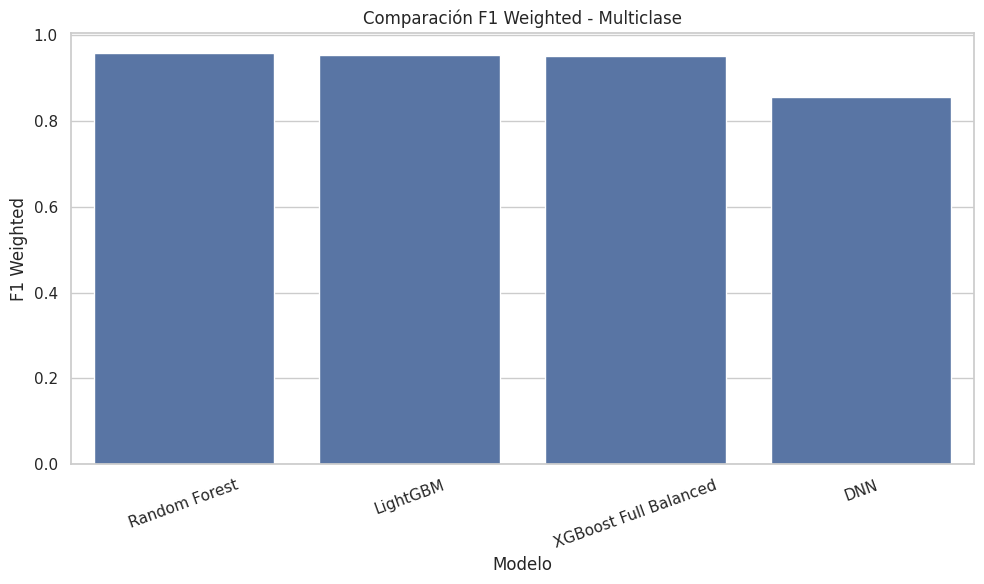

In [7]:
# ---------------------------------------------------------
# Gráfico principal de comparación multiclase
# usando F1 Weighted
# ---------------------------------------------------------
if not multiclass_results.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=multiclass_results,
        x="model",
        y="f1_weighted"
    )
    plt.title("Comparación F1 Weighted - Multiclase")
    plt.xlabel("Modelo")
    plt.ylabel("F1 Weighted")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

8. Comparación multiclase: métricas weighted

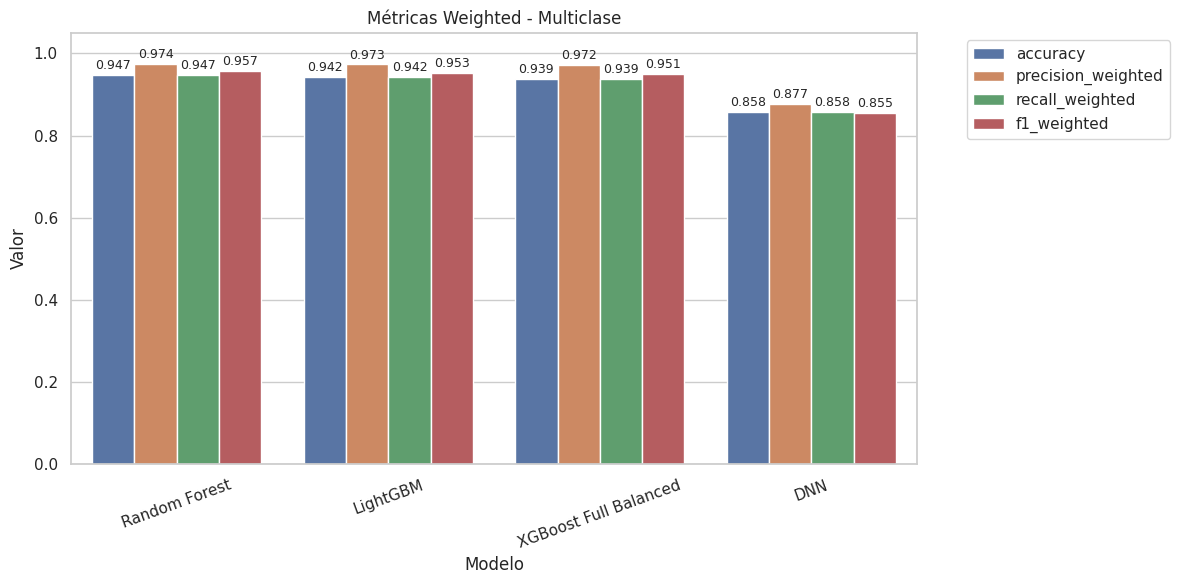

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/full_notebooks/images/figura_metricas_weighted_multiclase.png


In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Crear carpeta de salida
# ---------------------------------------------------------
output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# Convierte el DataFrame multiclase a formato largo
# para comparar varias métricas en una sola gráfica
# ---------------------------------------------------------
if not multiclass_results.empty:
    weighted_cols = [
        c for c in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]
        if c in multiclass_results.columns
    ]

    multiclass_weighted = multiclass_results.melt(
        id_vars=["model", "task"],
        value_vars=weighted_cols,
        var_name="metric",
        value_name="value"
    )

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=multiclass_weighted,
        x="model",
        y="value",
        hue="metric"
    )

    plt.title("Métricas Weighted - Multiclase")
    plt.xlabel("Modelo")
    plt.ylabel("Valor")
    plt.xticks(rotation=20)
    plt.ylim(0, 1.05)  # deja espacio para las etiquetas
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # ---------------------------------------------------------
    # Agregar valores sobre cada barra
    # ---------------------------------------------------------
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

    plt.tight_layout()

    # ---------------------------------------------------------
    # Guardar imagen
    # ---------------------------------------------------------
    save_path = os.path.join(output_dir, "figura_metricas_weighted_multiclase.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Imagen guardada en:", os.path.abspath(save_path))

9. Comparación multiclase: métricas macro

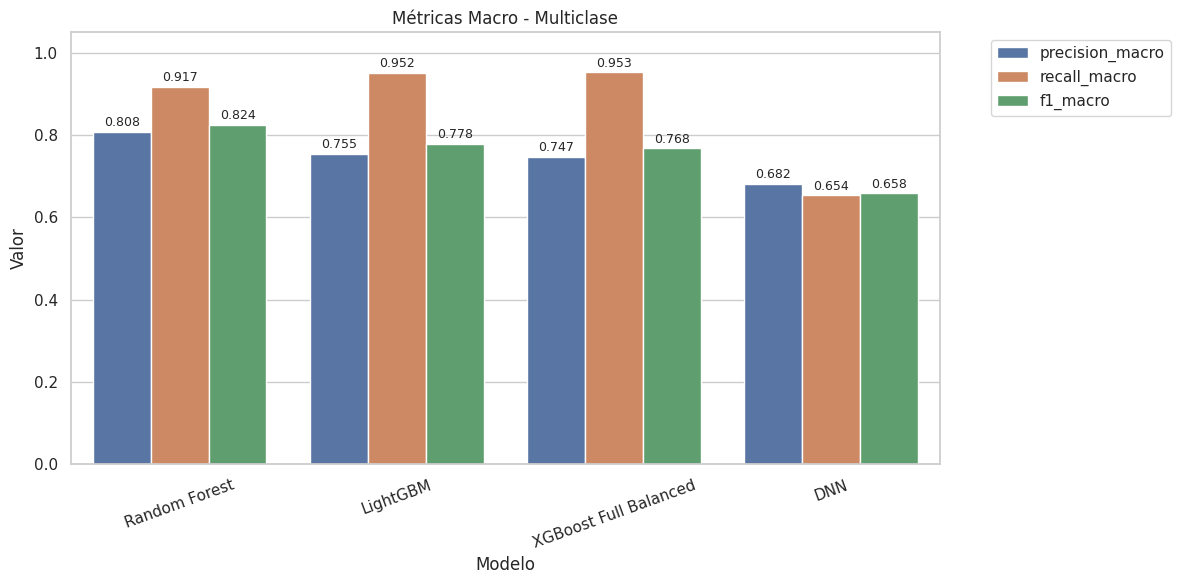

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/full_notebooks/images/figura_metricas_macro_multiclase.png


In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

if not multiclass_results.empty:
    macro_cols = [
        c for c in ["precision_macro", "recall_macro", "f1_macro"]
        if c in multiclass_results.columns
    ]

    multiclass_macro = multiclass_results.melt(
        id_vars=["model", "task"],
        value_vars=macro_cols,
        var_name="metric",
        value_name="value"
    )

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=multiclass_macro,
        x="model",
        y="value",
        hue="metric"
    )

    plt.title("Métricas Macro - Multiclase")
    plt.xlabel("Modelo")
    plt.ylabel("Valor")
    plt.xticks(rotation=20)
    plt.ylim(0, 1.05)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

    plt.tight_layout()

    save_path = os.path.join(output_dir, "figura_metricas_macro_multiclase.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Imagen guardada en:", os.path.abspath(save_path))

10. Comparación binaria: F1

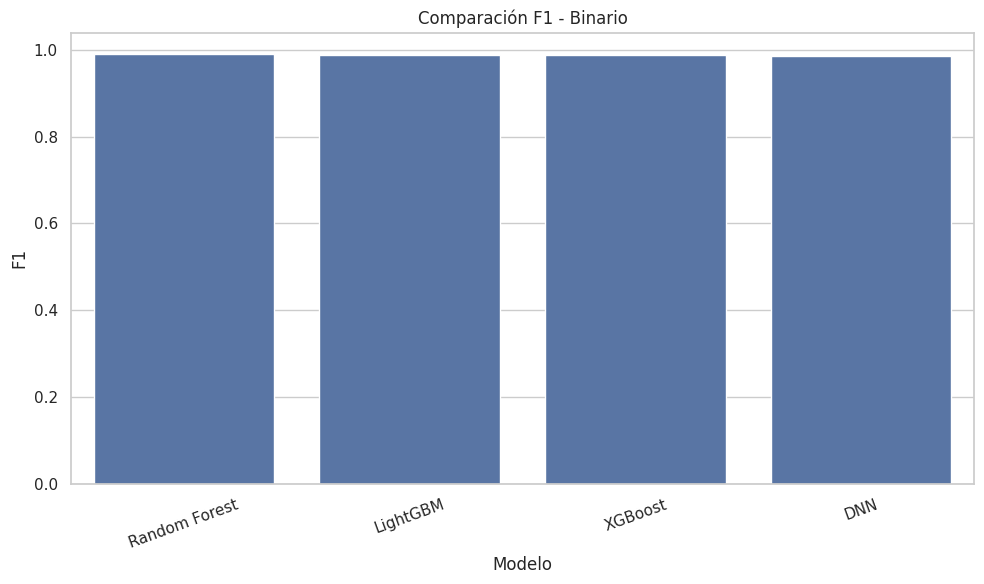

In [10]:
# ---------------------------------------------------------
# Gráfico principal de comparación binaria usando F1
# ---------------------------------------------------------
if not binary_results.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=binary_results,
        x="model",
        y="f1"
    )
    plt.title("Comparación F1 - Binario")
    plt.xlabel("Modelo")
    plt.ylabel("F1")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

11. Comparación binaria: ROC-AUC

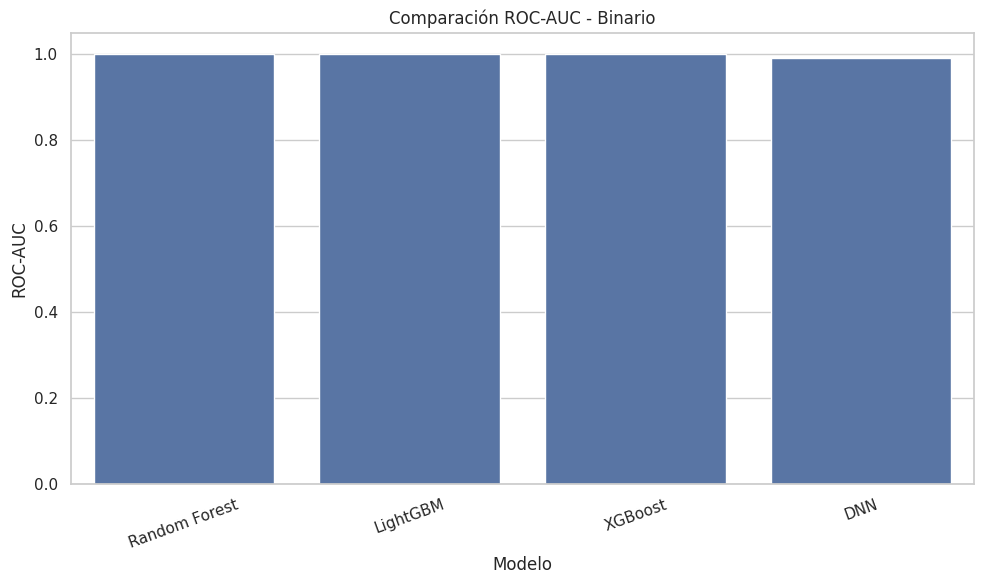

In [11]:
# ---------------------------------------------------------
# Si existe la métrica roc_auc, la grafica
# ---------------------------------------------------------
if not binary_results.empty and "roc_auc" in binary_results.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=binary_results,
        x="model",
        y="roc_auc"
    )
    plt.title("Comparación ROC-AUC - Binario")
    plt.xlabel("Modelo")
    plt.ylabel("ROC-AUC")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

12. Comparación binaria: métricas completas

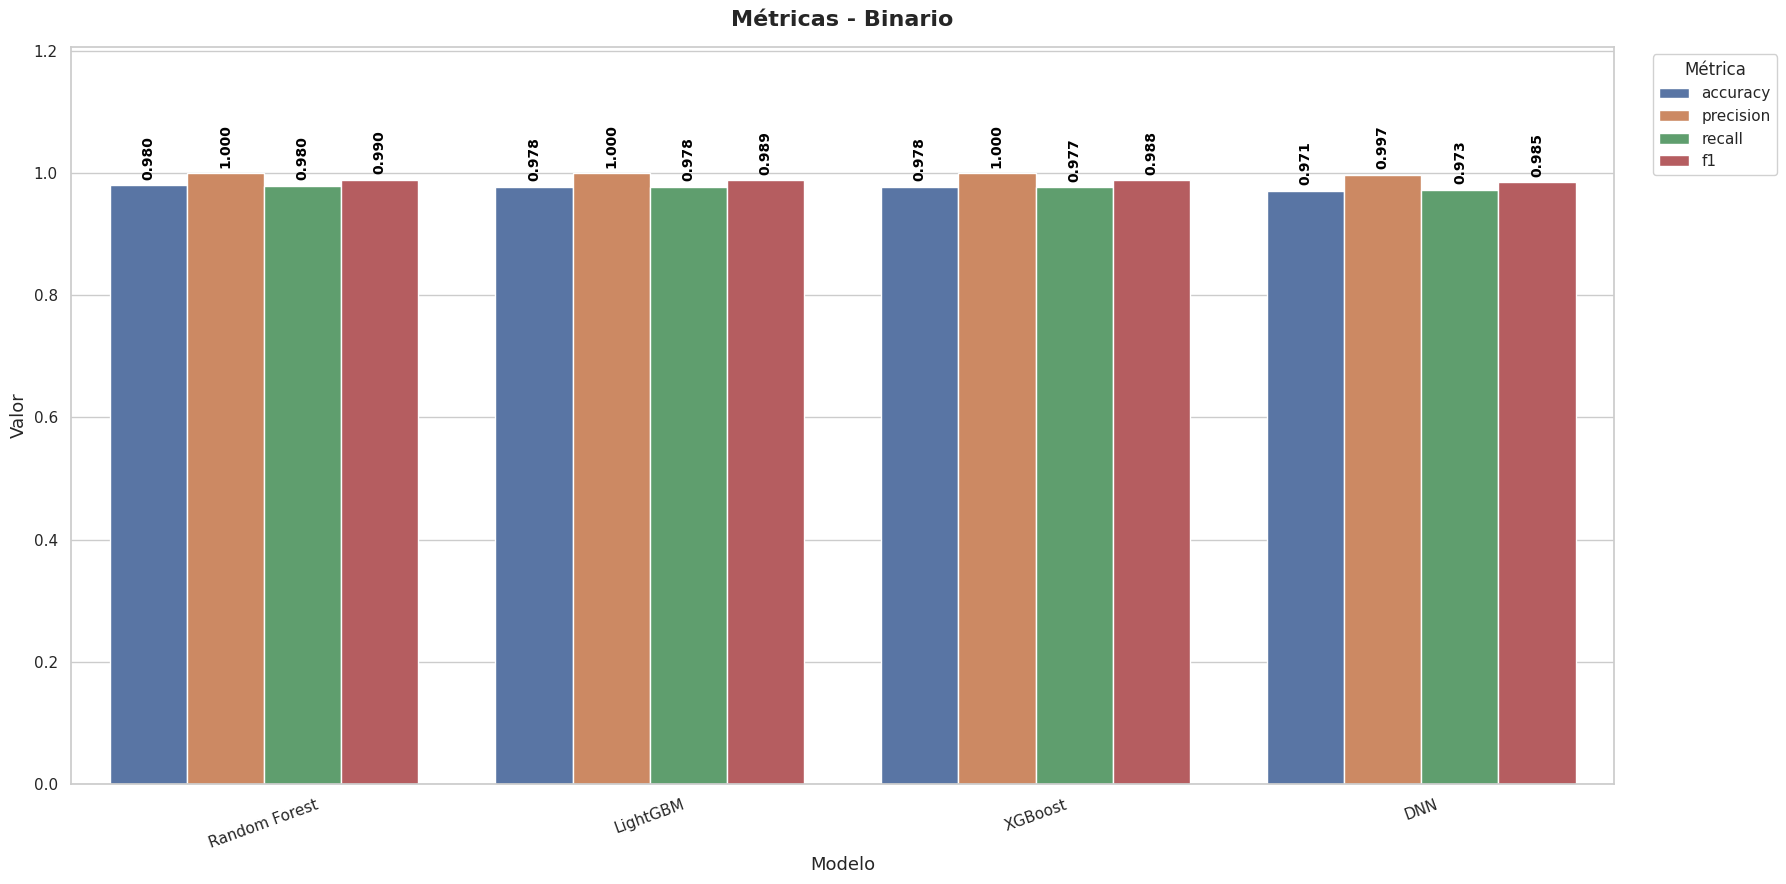

In [30]:
images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

if not binary_results.empty:
    binary_metric_cols = [
        c for c in ["accuracy", "precision", "recall", "f1", "auc"]
        if c in binary_results.columns
    ]
    binary_metrics = binary_results.melt(
        id_vars=["model", "task"],
        value_vars=binary_metric_cols,
        var_name="metric",
        value_name="value"
    )

    fig, ax = plt.subplots(figsize=(18, 9))

    sns.barplot(
        data=binary_metrics,
        x="model",
        y="value",
        hue="metric",
        ax=ax
    )

    ax.set_title("Métricas - Binario", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Modelo", fontsize=13)
    ax.set_ylabel("Valor", fontsize=13)
    ax.tick_params(axis="x", rotation=20, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

    for container in ax.containers:
        labels = ax.bar_label(
            container,
            fmt="%.3f",
            padding=4,
            fontsize=10,
            fontweight="bold",
            color="black",
        )
        for label in labels:
            label.set_rotation(90)
            label.set_va("bottom")
            label.set_ha("center")

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=11,
        title="Métrica",
        title_fontsize=12,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(
        os.path.join(images_dir, "binary_metrics_comparison.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

13. Mejores modelos por tarea

In [13]:
# ---------------------------------------------------------
# Construye una tabla resumen con el mejor modelo
# para cada tarea:
# - multiclase
# - binario
# ---------------------------------------------------------
summary_rows = []

# Mejor modelo multiclase
if not multiclass_results.empty:
    best_multi = multiclass_results.sort_values(
        by="f1_weighted",
        ascending=False
    ).iloc[0]

    summary_rows.append({
        "task": "multiclass",
        "best_model": best_multi["model"],
        "main_metric": "f1_weighted",
        "score": best_multi["f1_weighted"]
    })

# Mejor modelo binario
if not binary_results.empty:
    best_bin = binary_results.sort_values(
        by="f1",
        ascending=False
    ).iloc[0]

    summary_rows.append({
        "task": "binary",
        "best_model": best_bin["model"],
        "main_metric": "f1",
        "score": best_bin["f1"]
    })

summary_table = pd.DataFrame(summary_rows)
summary_table

,task,best_model,main_metric,score
0,multiclass,Random Forest,f1_weighted,0.956986
1,binary,Random Forest,f1,0.989592


14. Mostrar tablas finales

In [14]:
# ---------------------------------------------------------
# Muestra:
# - tabla resumen de mejores modelos
# - tabla multiclase completa
# - tabla binaria completa
# ---------------------------------------------------------
print("Resumen de mejores modelos:")
display(summary_table)

print("Comparación multiclase:")
display(multiclass_results)

print("Comparación binaria:")
display(binary_results)

Resumen de mejores modelos:


,task,best_model,main_metric,score
0,multiclass,Random Forest,f1_weighted,0.956986
1,binary,Random Forest,f1,0.989592


Comparación multiclase:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,task
0,Random Forest,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290,multiclass
1,LightGBM,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039,multiclass
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743,multiclass
3,DNN,0.858036,0.877164,0.858036,0.855430,0.681876,0.653672,0.658307,multiclass


Comparación binaria:


,model,accuracy,precision,recall,f1,roc_auc,task
0,Random Forest,0.980129,0.999739,0.979650,0.989592,0.998654,binary
1,LightGBM,0.978305,0.999759,0.977739,0.988626,0.998965,binary
2,XGBoost,0.977875,0.999725,0.977326,0.988399,0.998773,binary
3,DNN,0.971413,0.997395,0.972897,0.984994,0.990358,binary


15. Guardar tablas finales

In [15]:
# ---------------------------------------------------------
# Guarda la tabla resumen
# ---------------------------------------------------------
summary_table.to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "global_results_summary.csv"),
    index=False
)

# ---------------------------------------------------------
# Guarda la comparación multiclase si existe
# ---------------------------------------------------------
if not multiclass_results.empty:
    multiclass_results.to_csv(
        os.path.join(config.FULL_ARTIFACTS_DIR, "multiclass_internal_comparison.csv"),
        index=False
    )

# ---------------------------------------------------------
# Guarda la comparación binaria si existe
# ---------------------------------------------------------
if not binary_results.empty:
    binary_results.to_csv(
        os.path.join(config.FULL_ARTIFACTS_DIR, "binary_internal_comparison.csv"),
        index=False
    )

print("Tablas finales guardadas.")

Tablas finales guardadas.


16. Guardar gráfica principal multiclase

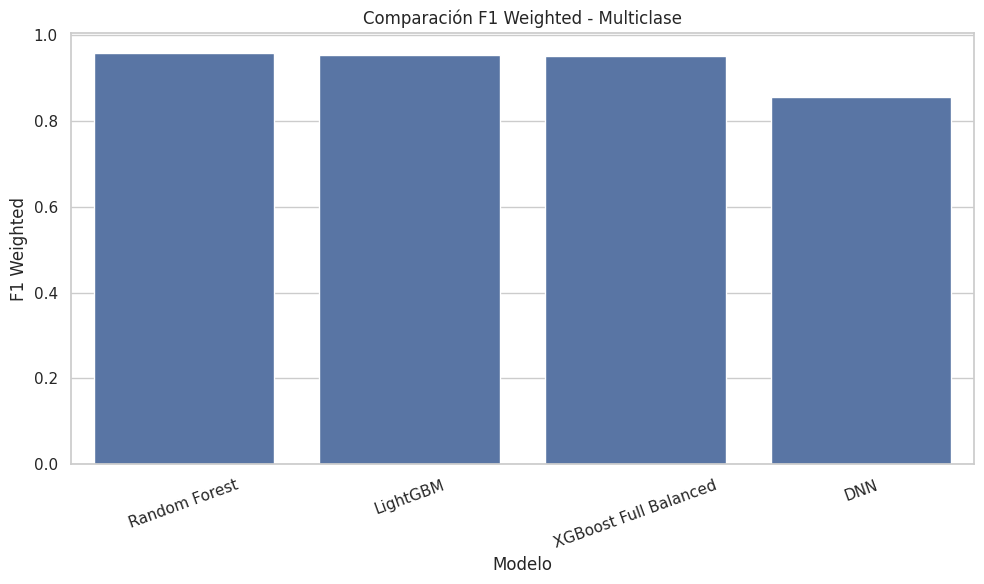

In [16]:
# ---------------------------------------------------------
# Guarda la gráfica principal multiclase en la carpeta images
# ---------------------------------------------------------
images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

if not multiclass_results.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=multiclass_results,
        x="model",
        y="f1_weighted"
    )
    plt.title("Comparación F1 Weighted - Multiclase")
    plt.xlabel("Modelo")
    plt.ylabel("F1 Weighted")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(
        os.path.join(images_dir, "comparison_multiclass_models.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

17. Guardar gráfica principal binaria

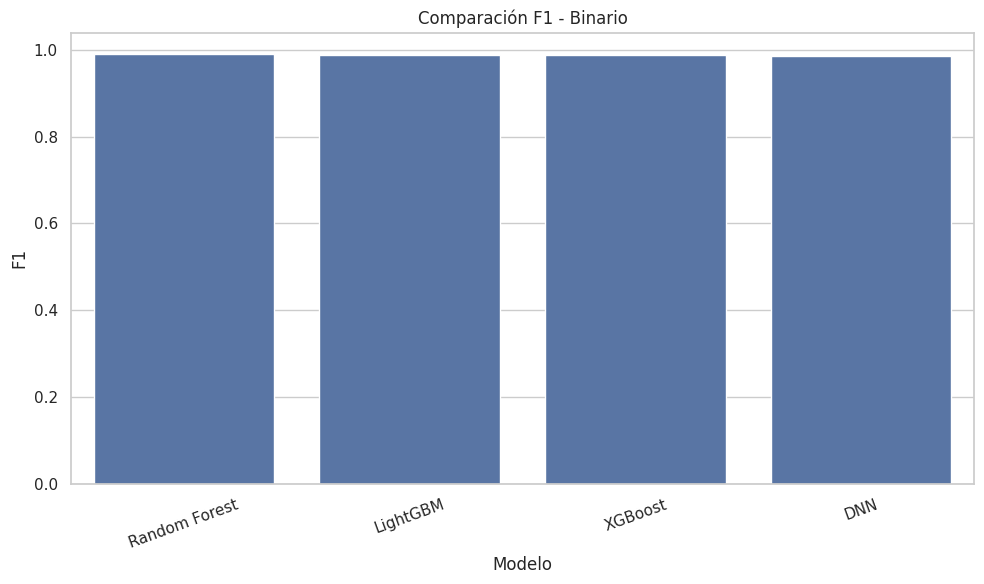

In [17]:
# ---------------------------------------------------------
# Guarda la gráfica principal binaria en la carpeta images
# ---------------------------------------------------------
images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

if not binary_results.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=binary_results,
        x="model",
        y="f1"
    )
    plt.title("Comparación F1 - Binario")
    plt.xlabel("Modelo")
    plt.ylabel("F1")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(
        os.path.join(images_dir, "comparison_binary_models.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

Matrices de confusion binarias

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# Ruta de la carpeta images dentro del proyecto
# ---------------------------------------------------------
images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

# ---------------------------------------------------------
# Función para cargar predicciones desde CSV,
# graficar matriz de confusión y guardarla como imagen
# ---------------------------------------------------------
def plot_binary_confusion_from_csv(csv_path, title, class_names):
    # Cargar archivo de predicciones
    df_pred = pd.read_csv(csv_path)

    # Extraer valores reales y predichos
    y_true = df_pred["y_true"]
    y_pred = df_pred["y_pred"]

    # Calcular matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # Crear figura
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        annot_kws={"size": 12}
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Crear nombre de archivo automático
    filename = title.lower().replace(" ", "_").replace("-", "").replace("__", "_") + ".png"

    # Guardar imagen
    plt.savefig(
        os.path.join(images_dir, filename),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Imagen guardada en:", os.path.join(images_dir, filename))

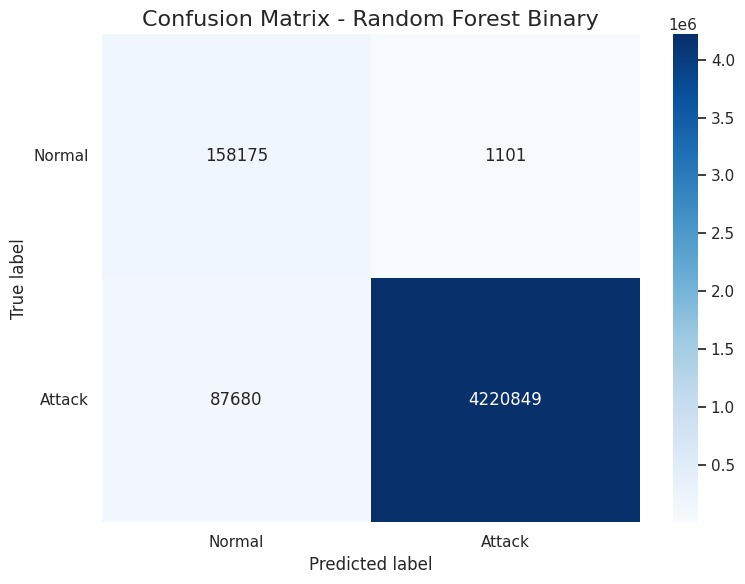

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_random_forest_binary.png


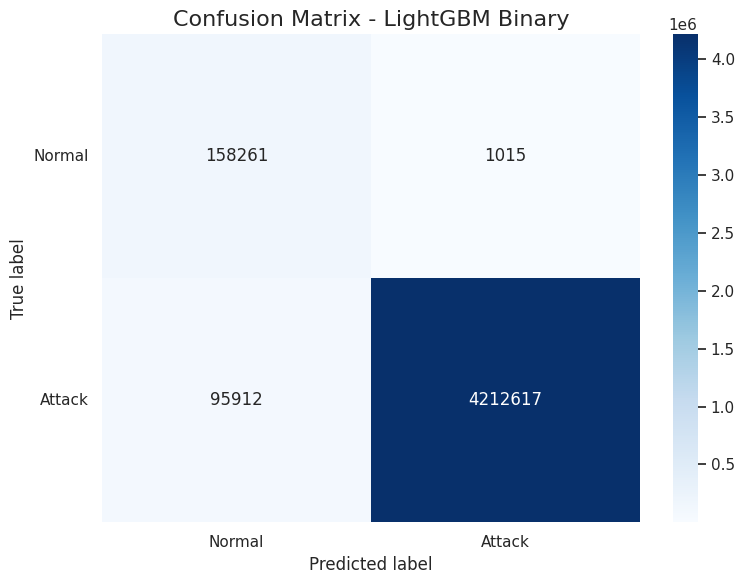

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_lightgbm_binary.png


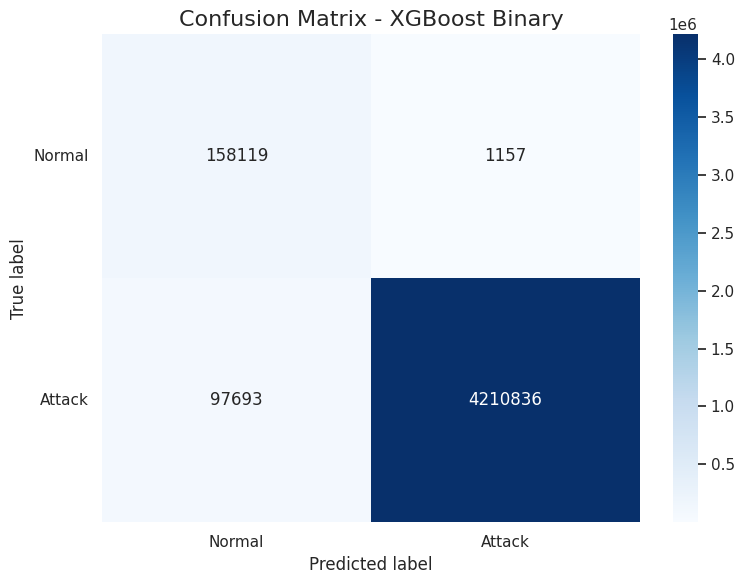

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_xgboost_binary.png


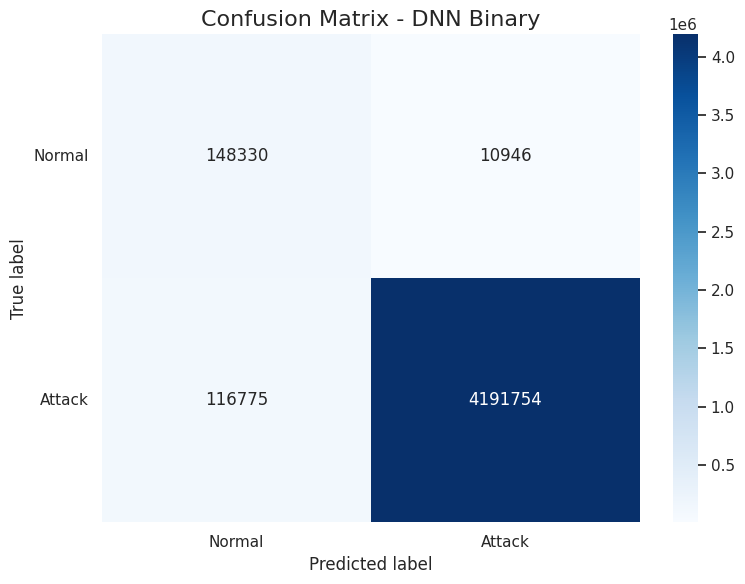

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_dnn_binary.png


In [19]:
binary_class_names = ["Normal", "Attack"]

plot_binary_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "rf_binary_predictions_full.csv"),
    "Confusion Matrix - Random Forest Binary",
    binary_class_names
)

plot_binary_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_binary_predictions_full.csv"),
    "Confusion Matrix - LightGBM Binary",
    binary_class_names
)

plot_binary_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_binary_predictions_full.csv"),
    "Confusion Matrix - XGBoost Binary",
    binary_class_names
)

plot_binary_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_binary_predictions_full.csv"),
    "Confusion Matrix - DNN Binary",
    binary_class_names
)

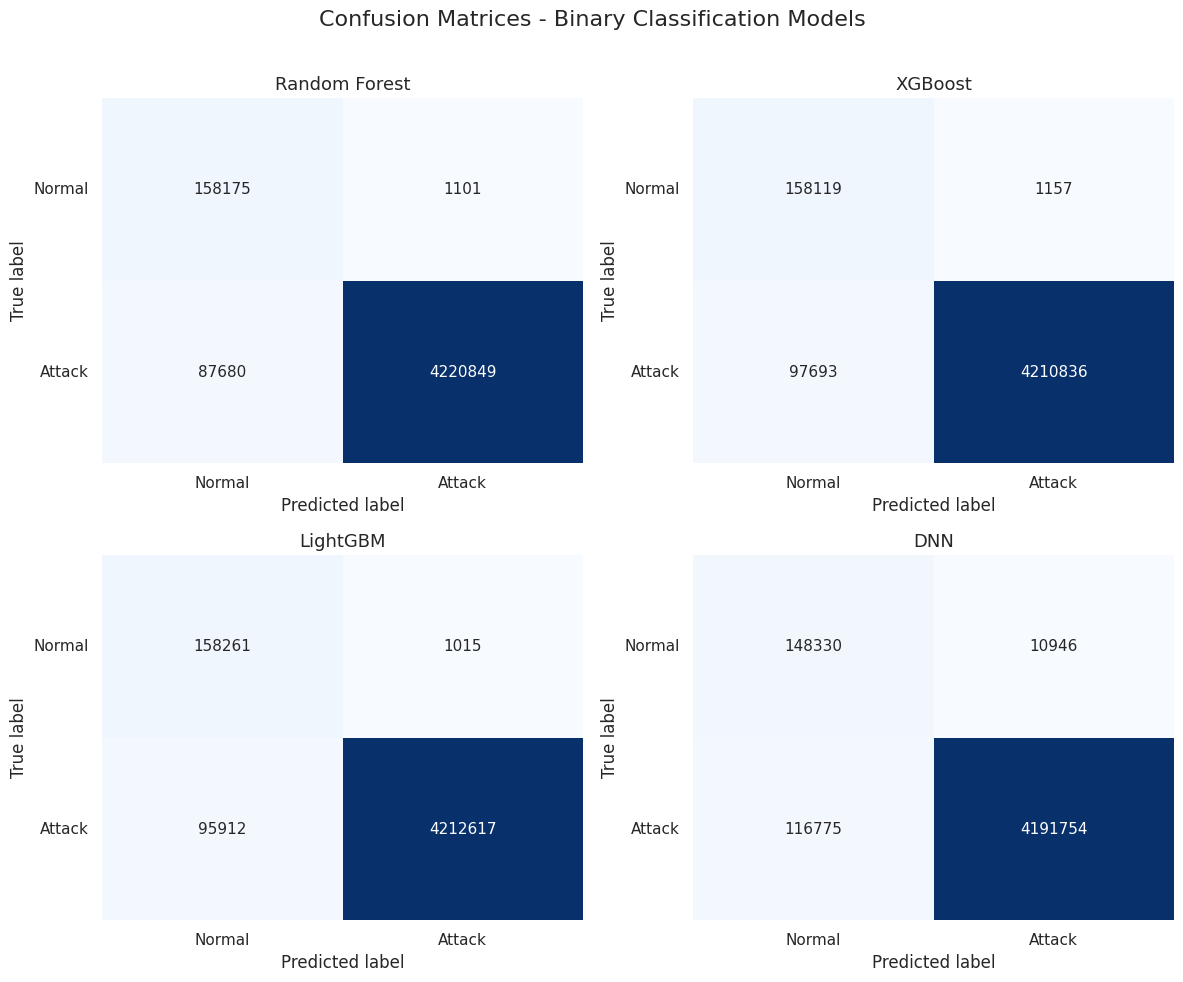

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrices_binary_all_models.png


In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# Carpeta de salida
# ---------------------------------------------------------
images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

# ---------------------------------------------------------
# Nombres de clases binarias
# ---------------------------------------------------------
binary_class_names = ["Normal", "Attack"]

# ---------------------------------------------------------
# Diccionario con modelos y archivos de predicción
# ---------------------------------------------------------
binary_prediction_files = {
    "Random Forest": os.path.join(config.FULL_ARTIFACTS_DIR, "rf_binary_predictions_full.csv"),
    "XGBoost": os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_binary_predictions_full.csv"),
    "LightGBM": os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_binary_predictions_full.csv"),
    "DNN": os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_binary_predictions_full.csv")
}

# ---------------------------------------------------------
# Crear figura de 2x2
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# ---------------------------------------------------------
# Recorrer archivos y graficar cada matriz
# ---------------------------------------------------------
for ax, (model_name, file_path) in zip(axes, binary_prediction_files.items()):
    df_pred = pd.read_csv(file_path)

    y_true = df_pred["y_true"]
    y_pred = df_pred["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=binary_class_names,
        yticklabels=binary_class_names,
        cbar=False,
        annot_kws={"size": 11},
        ax=ax
    )

    ax.set_title(f"{model_name}", fontsize=13)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

# ---------------------------------------------------------
# Ajustar layout general
# ---------------------------------------------------------
plt.suptitle("Confusion Matrices - Binary Classification Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# ---------------------------------------------------------
# Guardar imagen en Proyecto_MBD/images
# ---------------------------------------------------------
output_path = os.path.join(images_dir, "confusion_matrices_binary_all_models.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Imagen guardada en:", output_path)

In [21]:
print([v for v in dir() if "y_" in v.lower()])
for v in [x for x in dir() if "y_" in x.lower()]:
    try:
        obj = globals()[v]
        print(v, type(obj), getattr(obj, "shape", "sin shape"))
    except:
        pass

['binary_class_names', 'binary_dnn', 'binary_frames', 'binary_metric_cols', 'binary_metrics', 'binary_ml', 'binary_prediction_files', 'binary_results', 'plot_binary_confusion_from_csv', 'summary_rows', 'summary_table', 'y_pred', 'y_true']
binary_class_names <class 'list'> sin shape
binary_dnn <class 'pandas.DataFrame'> (1, 7)
binary_frames <class 'list'> sin shape
binary_metric_cols <class 'list'> sin shape
binary_metrics <class 'pandas.DataFrame'> (16, 4)
binary_ml <class 'pandas.DataFrame'> (3, 7)
binary_prediction_files <class 'dict'> sin shape
binary_results <class 'pandas.DataFrame'> (4, 7)
plot_binary_confusion_from_csv <class 'function'> sin shape
summary_rows <class 'list'> sin shape
summary_table <class 'pandas.DataFrame'> (2, 4)
y_pred <class 'pandas.Series'> (4467805,)
y_true <class 'pandas.Series'> (4467805,)


In [22]:
# ---------------------------------------------------------
# Librerías necesarias
# ---------------------------------------------------------
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# Ruta raíz del proyecto
# Asumiendo que el notebook está dentro de /notebooks
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Carpeta de salida para imágenes
# ---------------------------------------------------------
images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

print("Las imágenes se guardarán en:", images_dir)

Las imágenes se guardarán en: /home/bryan_santanderaragon/Proyecto_MBD/images


In [23]:
# ---------------------------------------------------------
# Cargar encoder del target multiclase para recuperar
# los nombres originales de las clases
# ---------------------------------------------------------
target_encoder = joblib.load(
    os.path.join(config.FULL_ARTIFACTS_DIR, "target_encoder_full_multiclass.pkl")
)

class_names = list(target_encoder.classes_)

print("Clases multiclase:")
print(class_names)

Clases multiclase:
['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


In [24]:
# ---------------------------------------------------------
# Función robusta para graficar matriz de confusión multiclase
# convirtiendo y_true y y_pred al mismo formato
# ---------------------------------------------------------
def plot_multiclass_confusion_from_csv(csv_path, title, class_names, output_filename, figsize=(14, 8)):
    # -----------------------------------------------------
    # Cargar archivo de predicciones
    # -----------------------------------------------------
    df_pred = pd.read_csv(csv_path)

    y_true = df_pred["y_true"]
    y_pred = df_pred["y_pred"]

    # -----------------------------------------------------
    # Convertir ambos al mismo tipo: texto
    # Si vienen numéricos, se transforman con el encoder
    # Si ya vienen en texto, se dejan como están
    # -----------------------------------------------------
    if pd.api.types.is_numeric_dtype(y_true):
        y_true = target_encoder.inverse_transform(y_true.astype(int))
    else:
        y_true = y_true.astype(str).values

    if pd.api.types.is_numeric_dtype(y_pred):
        y_pred = target_encoder.inverse_transform(y_pred.astype(int))
    else:
        y_pred = y_pred.astype(str).values

    # -----------------------------------------------------
    # Construir matriz de confusión respetando el orden
    # de class_names
    # -----------------------------------------------------
    cm = confusion_matrix(y_true, y_pred, labels=class_names)

    # -----------------------------------------------------
    # Graficar con heatmap
    # -----------------------------------------------------
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        annot_kws={"size": 9}
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    # -----------------------------------------------------
    # Guardar imagen
    # -----------------------------------------------------
    output_path = os.path.join(images_dir, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Imagen guardada en:", output_path)

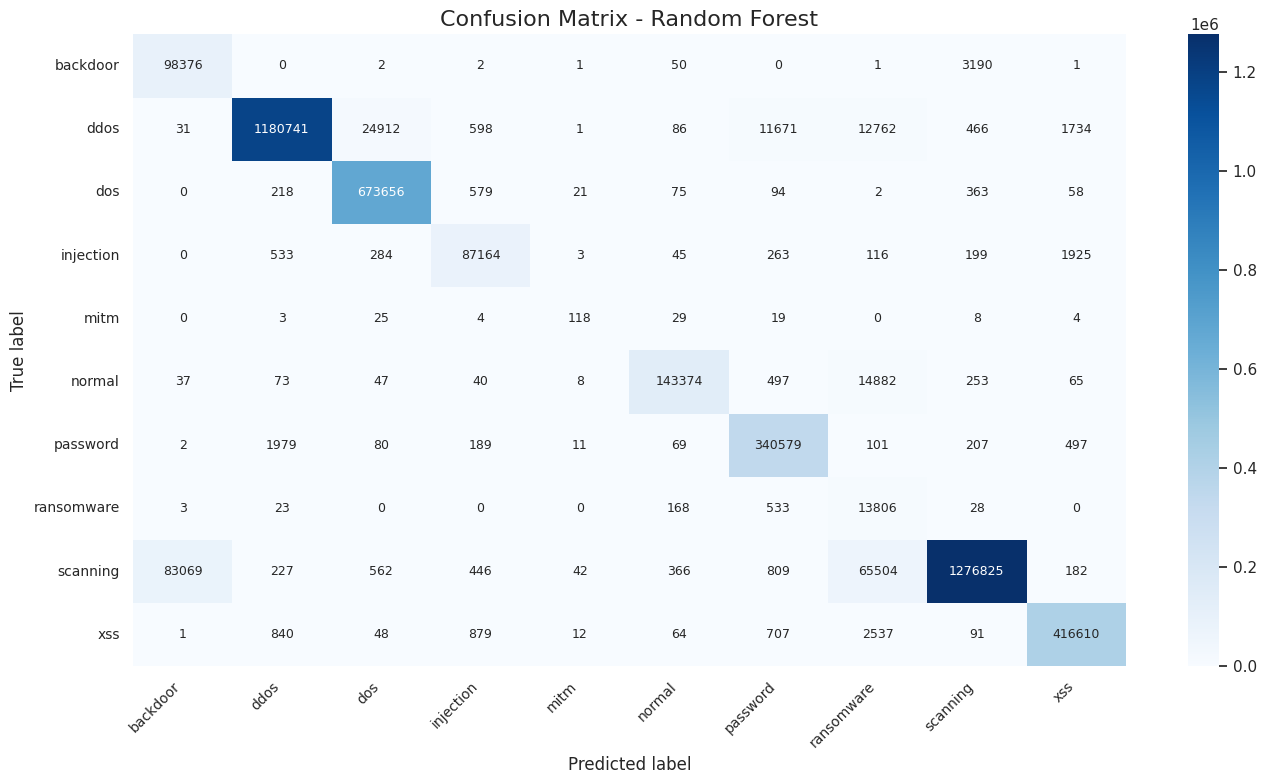

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_rf_multiclass.png


In [25]:
plot_multiclass_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "rf_predictions_full.csv"),
    "Confusion Matrix - Random Forest",
    class_names,
    "confusion_matrix_rf_multiclass.png",
    figsize=(14, 8)
)

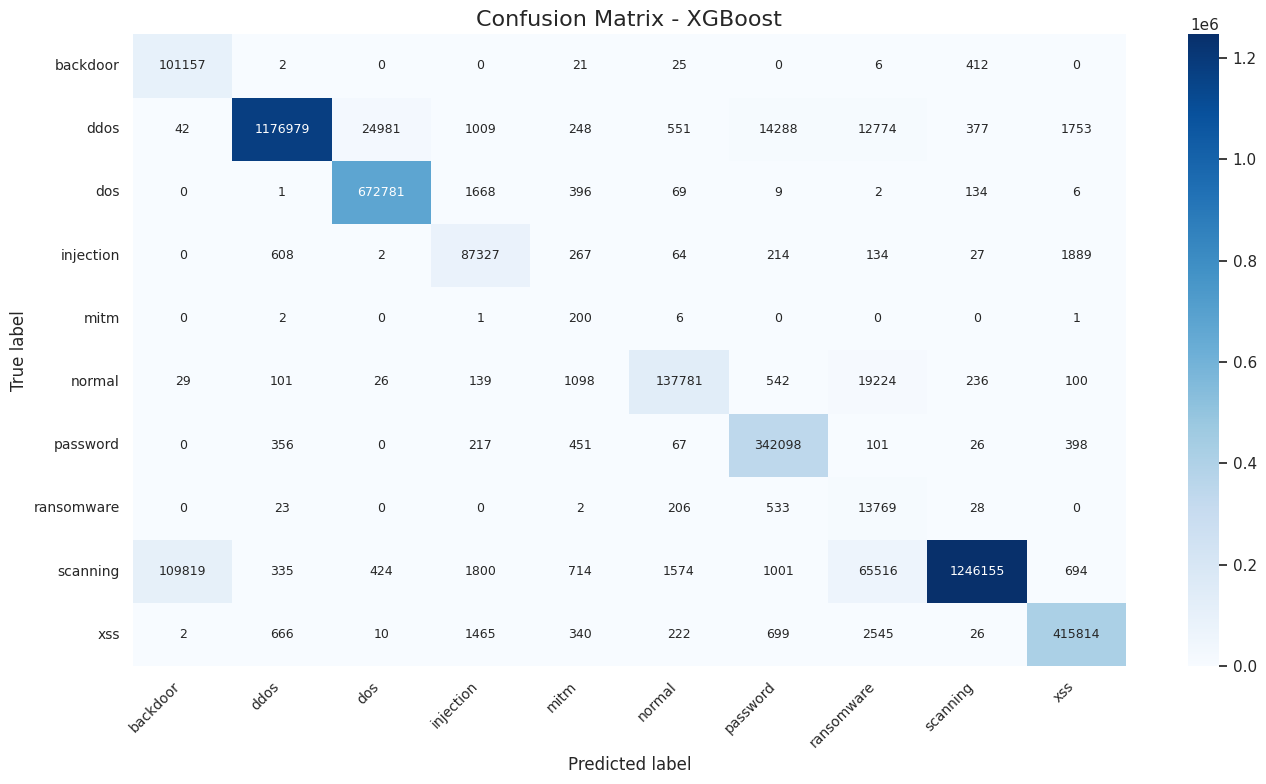

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_xgb_multiclass.png


In [26]:
plot_multiclass_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_predictions_full.csv"),
    "Confusion Matrix - XGBoost",
    class_names,
    "confusion_matrix_xgb_multiclass.png",
    figsize=(14, 8)
)

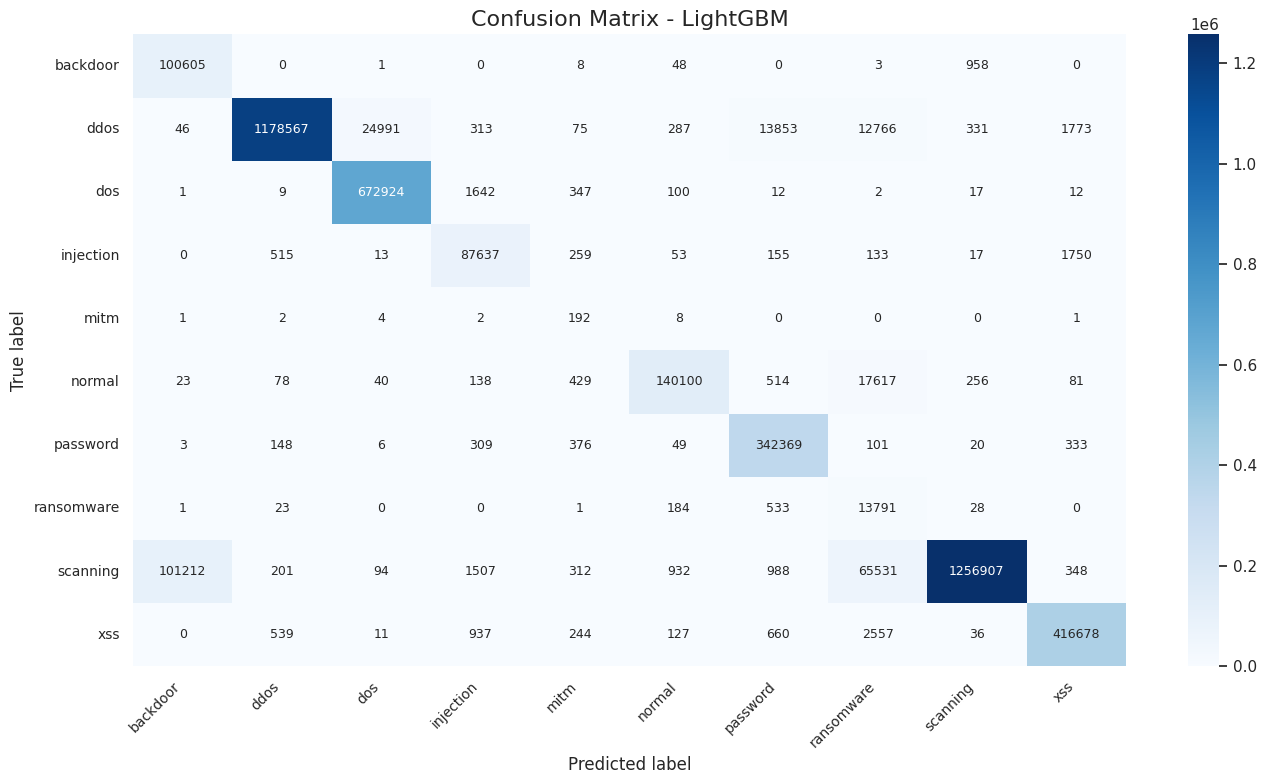

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_lgb_multiclass.png


In [27]:
plot_multiclass_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_predictions_full.csv"),
    "Confusion Matrix - LightGBM",
    class_names,
    "confusion_matrix_lgb_multiclass.png",
    figsize=(14, 8)
)

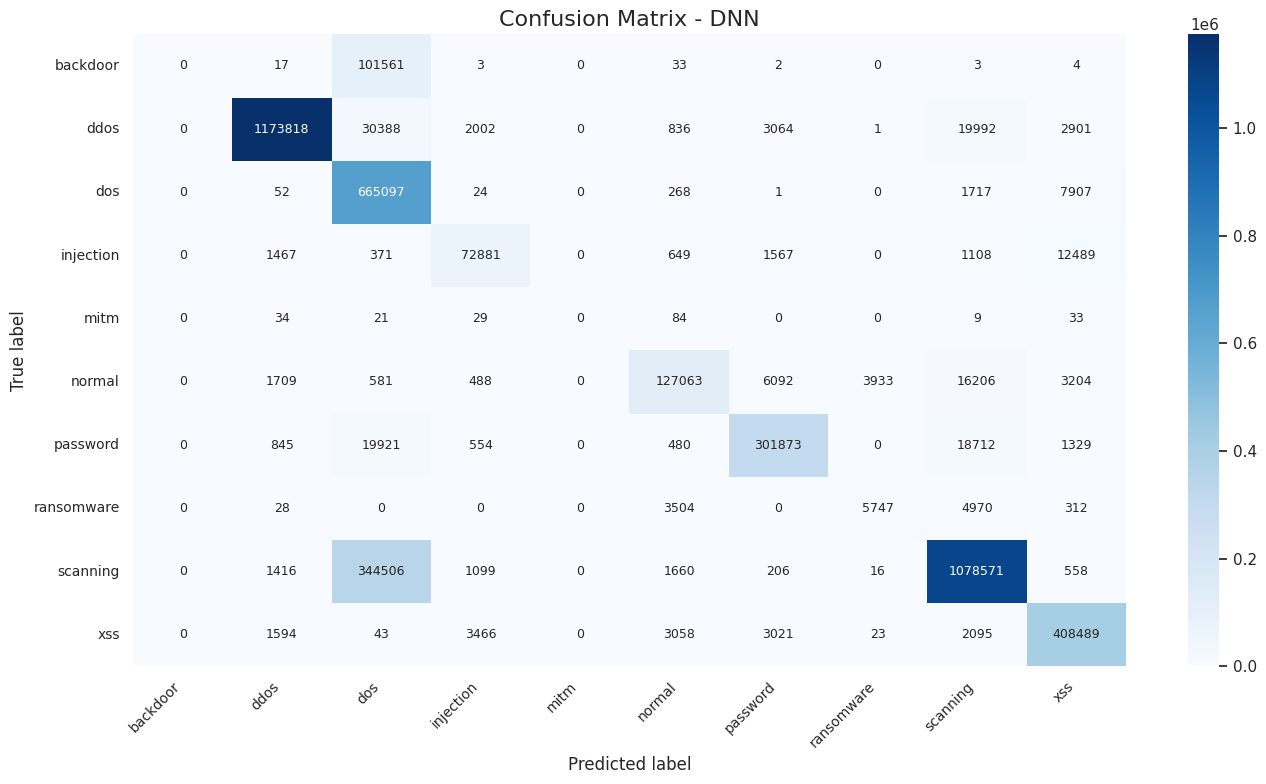

Imagen guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/confusion_matrix_dnn_multiclass.png


In [28]:
plot_multiclass_confusion_from_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_multiclass_predictions_full.csv"),
    "Confusion Matrix - DNN",
    class_names,
    "confusion_matrix_dnn_multiclass.png",
    figsize=(14, 8)
)